In [1]:
import shutil
import os

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"
print(shutil.which("latex"))

# Model tester function
import numpy as np
import matplotlib.pyplot as plt

from material_models import *
from structure_model import *

import os
from pathlib import Path

import json
import pprint

# Use latex for plots
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

C:\Users\Miguel.MIGUEL-DESK\AppData\Local\Programs\MiKTeX\miktex\bin\x64\latex.EXE


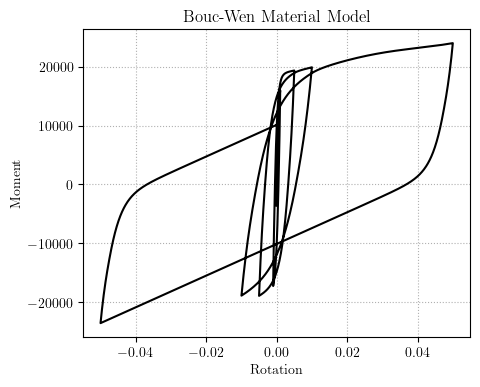

In [2]:
# Testing Pelliciari's plastic hinge model

# -----------------------------------------------------------------------
# Structure's Parameters
# ------------------------------------------------------------------------
    
E   = 44.8e9      # Young's Modulus of Concrete (Pa) (GPa)
I   = 0.9*0.1825  # Moment of Inertia (m4)                                       
L   = 6.0         # Length of Column (m)
NL = 1.0

mass = 262914      # Mass of structure (kg)
itheta = 2075226   # Rotational Moment of Inertia of Structure (kg-m2)
    
# ------------------------------------------------------------------------
# Plastic Hinge Parameters (BWBN)
# ------------------------------------------------------------------------
    
Fy       = 38432000
thetay   = 0.001
xu       = 10*thetay
    
alpha    = 0.007
ko       = Fy/thetay
n        = 1.28
eta      = 0.0
beta     = 17000/(1 + (1 - NL)*17000)

rhoeps   = 0.0
rhox     = NL*0.25 # 0.11
phi      = 1.6
deltak   = NL*15.0 # 47.0 Real = 40
deltaf   = NL*0.50  # 0.5
    
sigma = 0.01
u     = 4.0
epsp  = 0.001
rhop  = 0.0
    
xmax  = 0
xmaxp = 0
    
# Convergence Parameters
    
tolerance  = 0.001
maxNumIter = 1000

''' Model Parameters
self.Fy = params[1]
self.xu = params[2]
self.alpha = params[3]
self.ko = params[4]
self.n = params[5]
self.eta = params[6]
self.beta = params[7]
self.rhoeps = params[8]
self.rhox = params[9]
self.phi = params[10]
self.deltak = params[11]
self.deltaf = params[12]
self.sigma = params[13]
self.u = params[14]
self.epsp = params[15]
self.rhop = params[16]
'''

parameters = [Fy, xu, alpha, ko, n, eta, beta, rhoeps, rhox, phi, deltak, deltaf, sigma, u, epsp, rhop]

plastic_hinge = DegradingBoucWenPelliciari(parameters)
plastic_hinge.reset_state()

# Test the material model
strains = createCyclicStrain(maxStrains=[0.0001, 0.001, 0.005, 0.01, 0.05], dStrain=0.0001)
strain_vec, stress_vec = material_test(plastic_hinge, strains[0])
strain_vec = np.array(strain_vec)
stress_vec = np.array(stress_vec)

# Create plot
plt.figure(figsize=(5, 4))
plt.plot(strain_vec, 0.001*stress_vec, label='Stress-Strain Curve', color='black')
plt.xlabel('Rotation')
plt.ylabel('Moment')
plt.title('Bouc-Wen Material Model')
plt.grid(linestyle=':')

plastic_hinge.reset_state()

[[1.  0.  0. ]
 [0.  0.1 0. ]
 [0.  0.  0.1]]
[[1.63520e+09 4.90560e+09 4.90560e+09]
 [4.90560e+09 5.80544e+10 9.81120e+09]
 [4.90560e+09 9.81120e+09 1.96224e+10]]
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
Warning... MaxIter Reached in Global Equilibrium
War

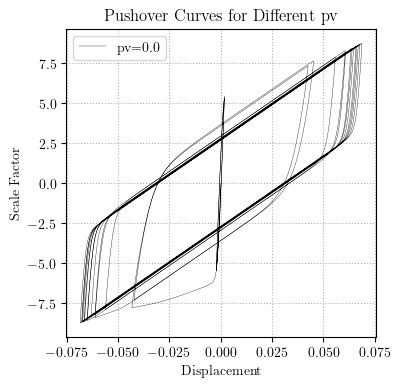

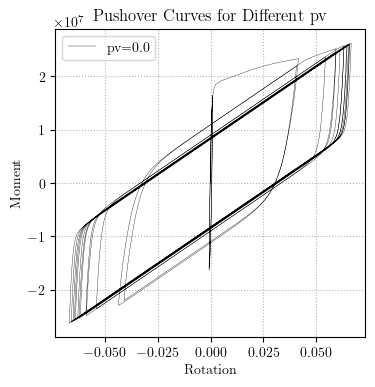

In [5]:
# Now, we can create the structural model with this new plastic hinge

def run_pushover(pv=1.0):
    ncolumns = 1
    h = L
    massdata = [1.0, 0.1, 0.1]
    damping = [0.02]
    weight = pv
    # Create the structure model
    plastic_hinge = DegradingBoucWenPelliciari(parameters)
    plastic_hinge.reset_state()

    # Create 1 copies of the plastic hinge model
    hingedata = [plastic_hinge] * 1
    model = InelasticFrame(ncolumns, E, I, h, hingedata, massdata, damping, weight, geometry="linear")
    
    # sf = np.linspace(0, 1.0, 1000)# Load the response_Reactions.out file
    response_data = np.loadtxt('response_Reactions.out', skiprows=0)
    # plt.plot(response_data[:, 2], label='Response Reactions', color='blue')
    sf = response_data[:, 2] / 200
    # Subsample sf every 100 elements
    sf = sf[::10]
    # sf = createCyclicStrain(maxStrains=[1.0, 2.0, 3.5, 4.2], dStrain=0.1)
    # sf = sf[0]

    pref = np.array([1.0, 0.0, 0.0])*1_000_000
    u0 = np.array([0.0, 0.0, 0.0])

    u = []
    rot = []
    mom = []
    for i in range(len(sf)):
        pf = sf[i] * pref
        u1 = load_step(pf, u0, model)
        u.append(u1[0])
        rot.append(u1[1])
        mom.append(model.cstate['stress'][-1])
        u0 = u1

    return sf, u, rot, mom

# Loop over multiple values of pv and generate 3 different plots
pv_values = [0.0]
greys = ['black', 'dimgray', 'gray', 'darkgray']


for idx, pv_val in enumerate(pv_values):
    sf, u, rot, mom = run_pushover(pv=pv_val)
    plt.figure(dpi=100, figsize=(4, 4))
    plt.plot(np.array(u)/6, 2*sf, label=f'pv={pv_val}', color=greys[idx % len(greys)], linewidth=0.25)
    plt.xlabel('Displacement')
    plt.ylabel('Scale Factor')
    plt.title('Pushover Curves for Different pv')
    plt.legend()
    plt.grid(linestyle=':')
    plt.show()

    plt.figure(dpi=100, figsize=(4, 4))
    plt.plot(rot, mom, label=f'pv={pv_val}', color=greys[idx % len(greys)], linewidth=0.25)
    plt.xlabel('Rotation')
    plt.ylabel('Moment')
    plt.title('Pushover Curves for Different pv')
    plt.legend()
    plt.grid(linestyle=':')
    plt.show()


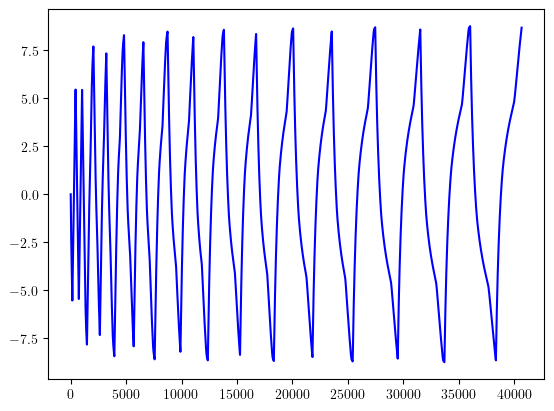

In [4]:
# Load the response_Reactions.out file
response_data = np.loadtxt('response_Reactions.out', skiprows=0)
plt.plot(response_data[:, 2]/100, label='Response Reactions', color='blue')